# data load

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

# 1. 열(Column) 생략 없이 전체 출력
#pd.set_option('display.max_columns', None)
# 2. 행(Row) 생략 없이 전체 출력 (데이터가 너무 많으면 주의!)
#pd.set_option('display.max_rows', None)
# 3. 출력되는 각 열의 너비 제한 해제 (내용이 길 때 유용)
#pd.set_option('display.max_colwidth', None)

In [2]:
# 1. FD0001 데이터 로드
columns = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]

train_df = pd.read_csv('CMAPSSData/train_FD001.txt', sep=r'\s+', header=None, names=columns)
test_df = pd.read_csv('CMAPSSData/test_FD001.txt', sep=r'\s+', header=None, names=columns)
rul_df = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

In [3]:
display(train_df)
display(test_df)
display(rul_df)

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,100.0,518.67,643.24,1599.45,1415.79,14.62,...,520.69,2388.00,8213.28,8.4715,0.03,394,2388,100.0,38.65,23.1974
13092,100,195,-0.0011,-0.0001,100.0,518.67,643.22,1595.69,1422.05,14.62,...,521.05,2388.09,8210.85,8.4512,0.03,395,2388,100.0,38.57,23.2771
13093,100,196,-0.0006,-0.0003,100.0,518.67,643.44,1593.15,1406.82,14.62,...,521.18,2388.04,8217.24,8.4569,0.03,395,2388,100.0,38.62,23.2051
13094,100,197,-0.0038,0.0001,100.0,518.67,643.26,1594.99,1419.36,14.62,...,521.33,2388.08,8220.48,8.4711,0.03,395,2388,100.0,38.66,23.2699


,RUL
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117


# train 데이터에 rul 생성 후 125 클리핑 & 수명 관련

In [4]:
# RUL_CLIPPING (CAP 120~130 중) CAP = 125로 고정 => 실험=> 다른 값으로 재실험
max_cycle = train_df.groupby('unit_nr')['time_cycles'].transform('max')
train_df['RUL'] = max_cycle - train_df['time_cycles']

C:\Users\skrke\AppData\Local\Temp\ipykernel_30712\2940326738.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='unit_nr', y='RUL', data=engine_lifespan, palette='viridis')


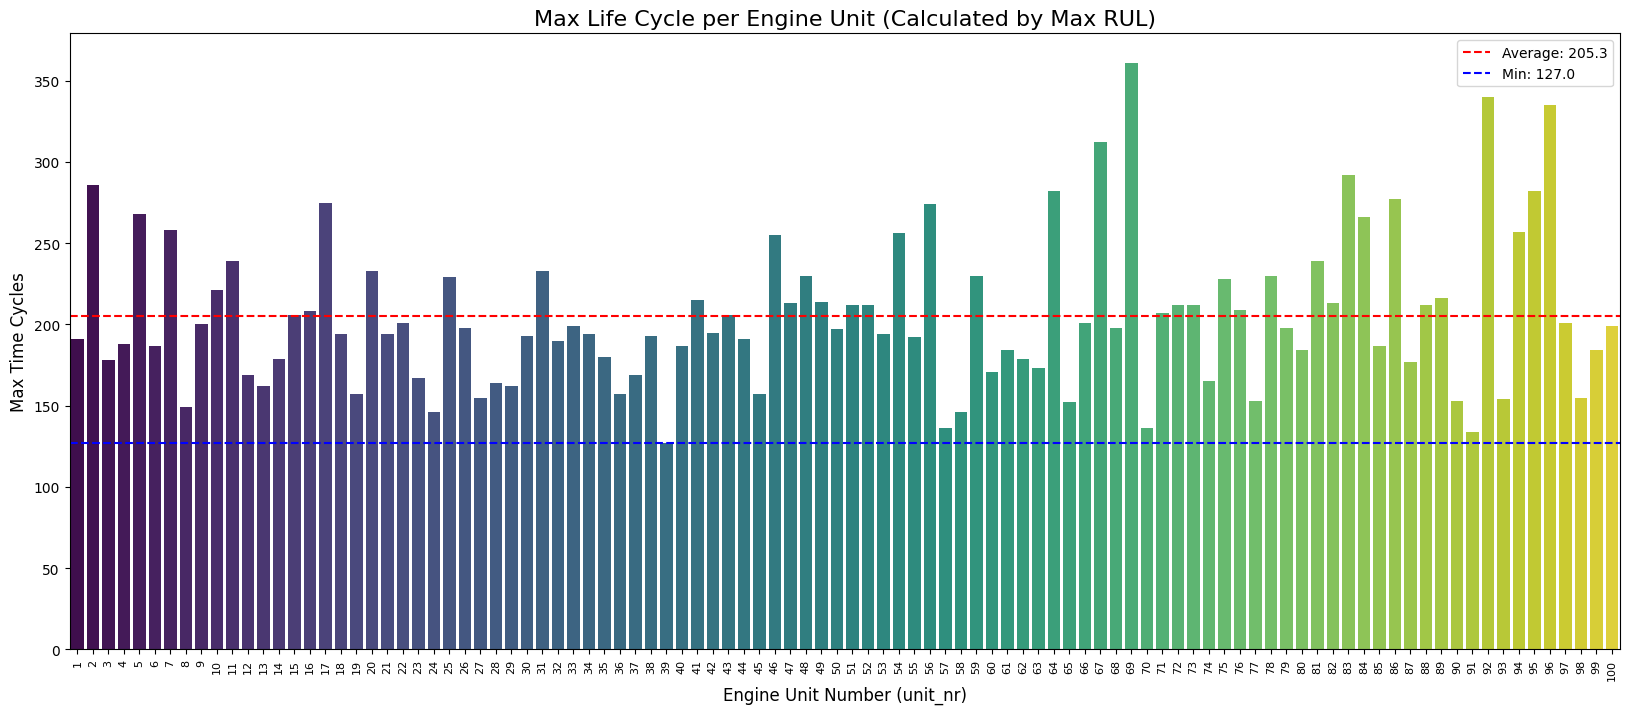

In [5]:
# 1. 엔진별 RUL의 최댓값(최대 수명) 데이터 추출
# groupby를 사용하여 각 unit_nr별로 RUL의 가장 큰 값을 가져옵니다.
engine_lifespan = train_df.groupby('unit_nr')['RUL'].max().reset_index()

# 2. 시각화 설정
plt.figure(figsize=(20, 8))
# y축을 'RUL'로 변경하여 시각화합니다.
sns.barplot(x='unit_nr', y='RUL', data=engine_lifespan, palette='viridis')

# 3. 그래프 디테일 추가
avg_life = engine_lifespan['RUL'].mean()
min_life = engine_lifespan['RUL'].min()

plt.axhline(avg_life, color='red', linestyle='--', label=f"Average: {avg_life:.1f}")
plt.axhline(min_life, color='blue', linestyle='--', label=f"Min: {min_life:.1f}")

plt.title('Max Life Cycle per Engine Unit (Calculated by Max RUL)', fontsize=16)
plt.xlabel('Engine Unit Number (unit_nr)', fontsize=12)
plt.ylabel('Max Time Cycles', fontsize=12)
plt.xticks(rotation=90, fontsize=8) 
plt.legend()

plt.show()

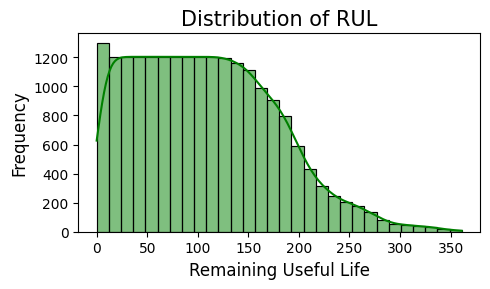

In [6]:
# 남은 수명별 카운트 시각화
# 1. 그래프 크기 설정 (단일 그래프에 적합한 사이즈)
plt.figure(figsize=(5, 3))

# 2. 히스토그램 및 밀도 추정 곡선(KDE) 그리기
sns.histplot(train_df['RUL'], bins=30, kde=True, color='green')

# 3. 그래프 제목 및 축 레이블 설정
plt.title('Distribution of RUL', fontsize=15)
plt.xlabel('Remaining Useful Life', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 4. 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

In [7]:
train_df['RUL'] = train_df['RUL'].clip(upper=125)

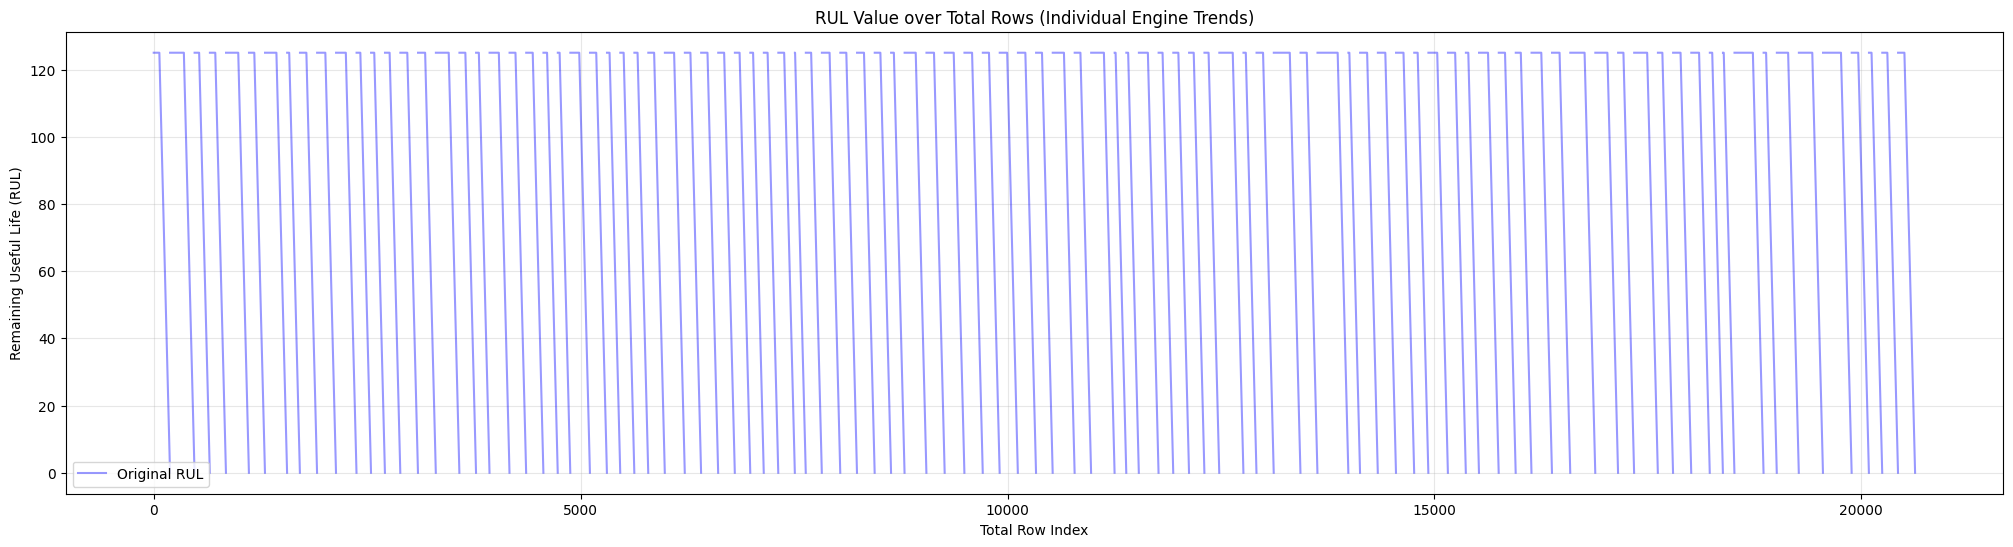

In [8]:
# rul값이 잘 들어가 있는지 시각적으로 확인
plt.figure(figsize=(25, 6))

# 유니크한 엔진 번호(unit_nr) 추출
units = train_df['unit_nr'].unique()

# 엔진별로 루프를 돌며 그래프를 그림 (선이 이어지는 것 방지)
for i, unit in enumerate(units):
    unit_data = train_df[train_df['unit_nr'] == unit]
    
    # 첫 번째 엔진에만 label을 붙여서 범례(legend)가 중복되지 않게 함
    label_orig = 'Original RUL' if i == 0 else ""
    label_clip = 'Clipped RUL (125)' if i == 0 else ""
    
    # 1. Original RUL (실선)
    plt.plot(unit_data.index, unit_data['RUL'], 
             color='blue', alpha=0.4, label=label_orig)

plt.title('RUL Value over Total Rows (Individual Engine Trends)')
plt.xlabel('Total Row Index')
plt.ylabel('Remaining Useful Life (RUL)')

# 범례 표시
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

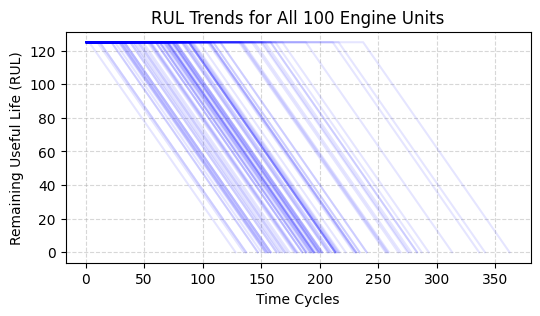

In [9]:
# unit_nr 100개의 rul 그래프 겹쳐 이상여부 확인하기
plt.figure(figsize=(6, 3))

# unit_nr별로 그룹화하여 반복문으로 그래프 그리기
for unit_nr, group in train_df.groupby('unit_nr'):
    plt.plot(group['time_cycles'], group['RUL'], color='blue', alpha=0.1) # 투명도를 낮게 설정

plt.xlabel('Time Cycles')
plt.ylabel('Remaining Useful Life (RUL)')
plt.title('RUL Trends for All 100 Engine Units')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

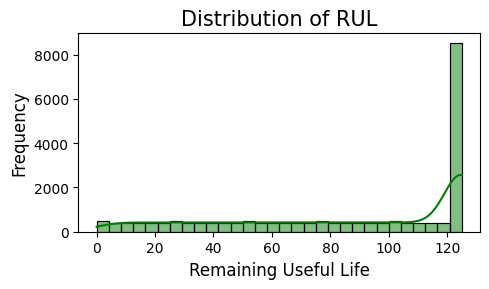

In [10]:
# 남은 수명별 카운트 시각화 (단일 그래프)

# 1. 그래프 크기 설정 (단일 그래프에 적합한 사이즈)
plt.figure(figsize=(5, 3))

# 2. 히스토그램 및 밀도 추정 곡선(KDE) 그리기
sns.histplot(train_df['RUL'], bins=30, kde=True, color='green')

# 3. 그래프 제목 및 축 레이블 설정
plt.title('Distribution of RUL', fontsize=15)
plt.xlabel('Remaining Useful Life', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 4. 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

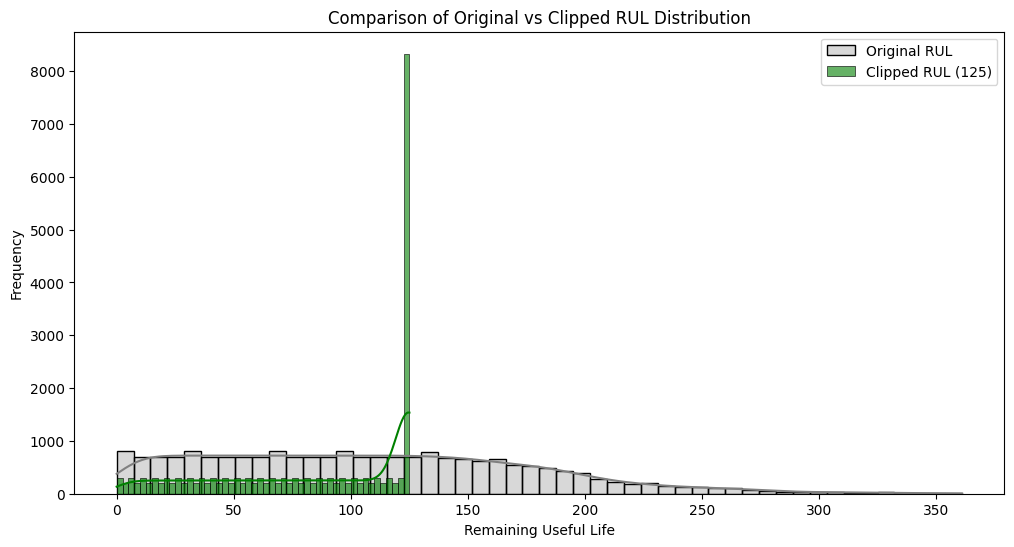

In [ ]:
########### 돌리지 않는 코드 #rul전/후 겹쳐보기 ###########
plt.figure(figsize=(12, 6))

# Original RUL
sns.histplot(train_df['RUL'], bins=50, kde=True, color='gray', label='Original RUL', alpha=0.3)

# RUL125
sns.histplot(train_df['RUL125'], bins=50, kde=True, color='green', label='Clipped RUL (125)', alpha=0.6)

plt.title('Comparison of Original vs Clipped RUL Distribution')
plt.xlabel('Remaining Useful Life')
plt.ylabel('Frequency')
plt.legend() # 범례 표시 필수
plt.show()

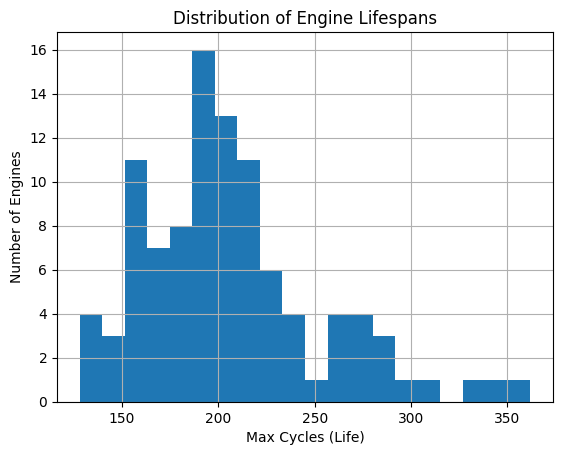

In [11]:
# 엔진들의 수명 분포 확인
max_cycles_per_unit = train_df.groupby('unit_nr')['time_cycles'].max()
max_cycles_per_unit.hist(bins=20)
plt.title('Distribution of Engine Lifespans')
plt.xlabel('Max Cycles (Life)')
plt.ylabel('Number of Engines')
plt.show()

# 센서 추이 확인

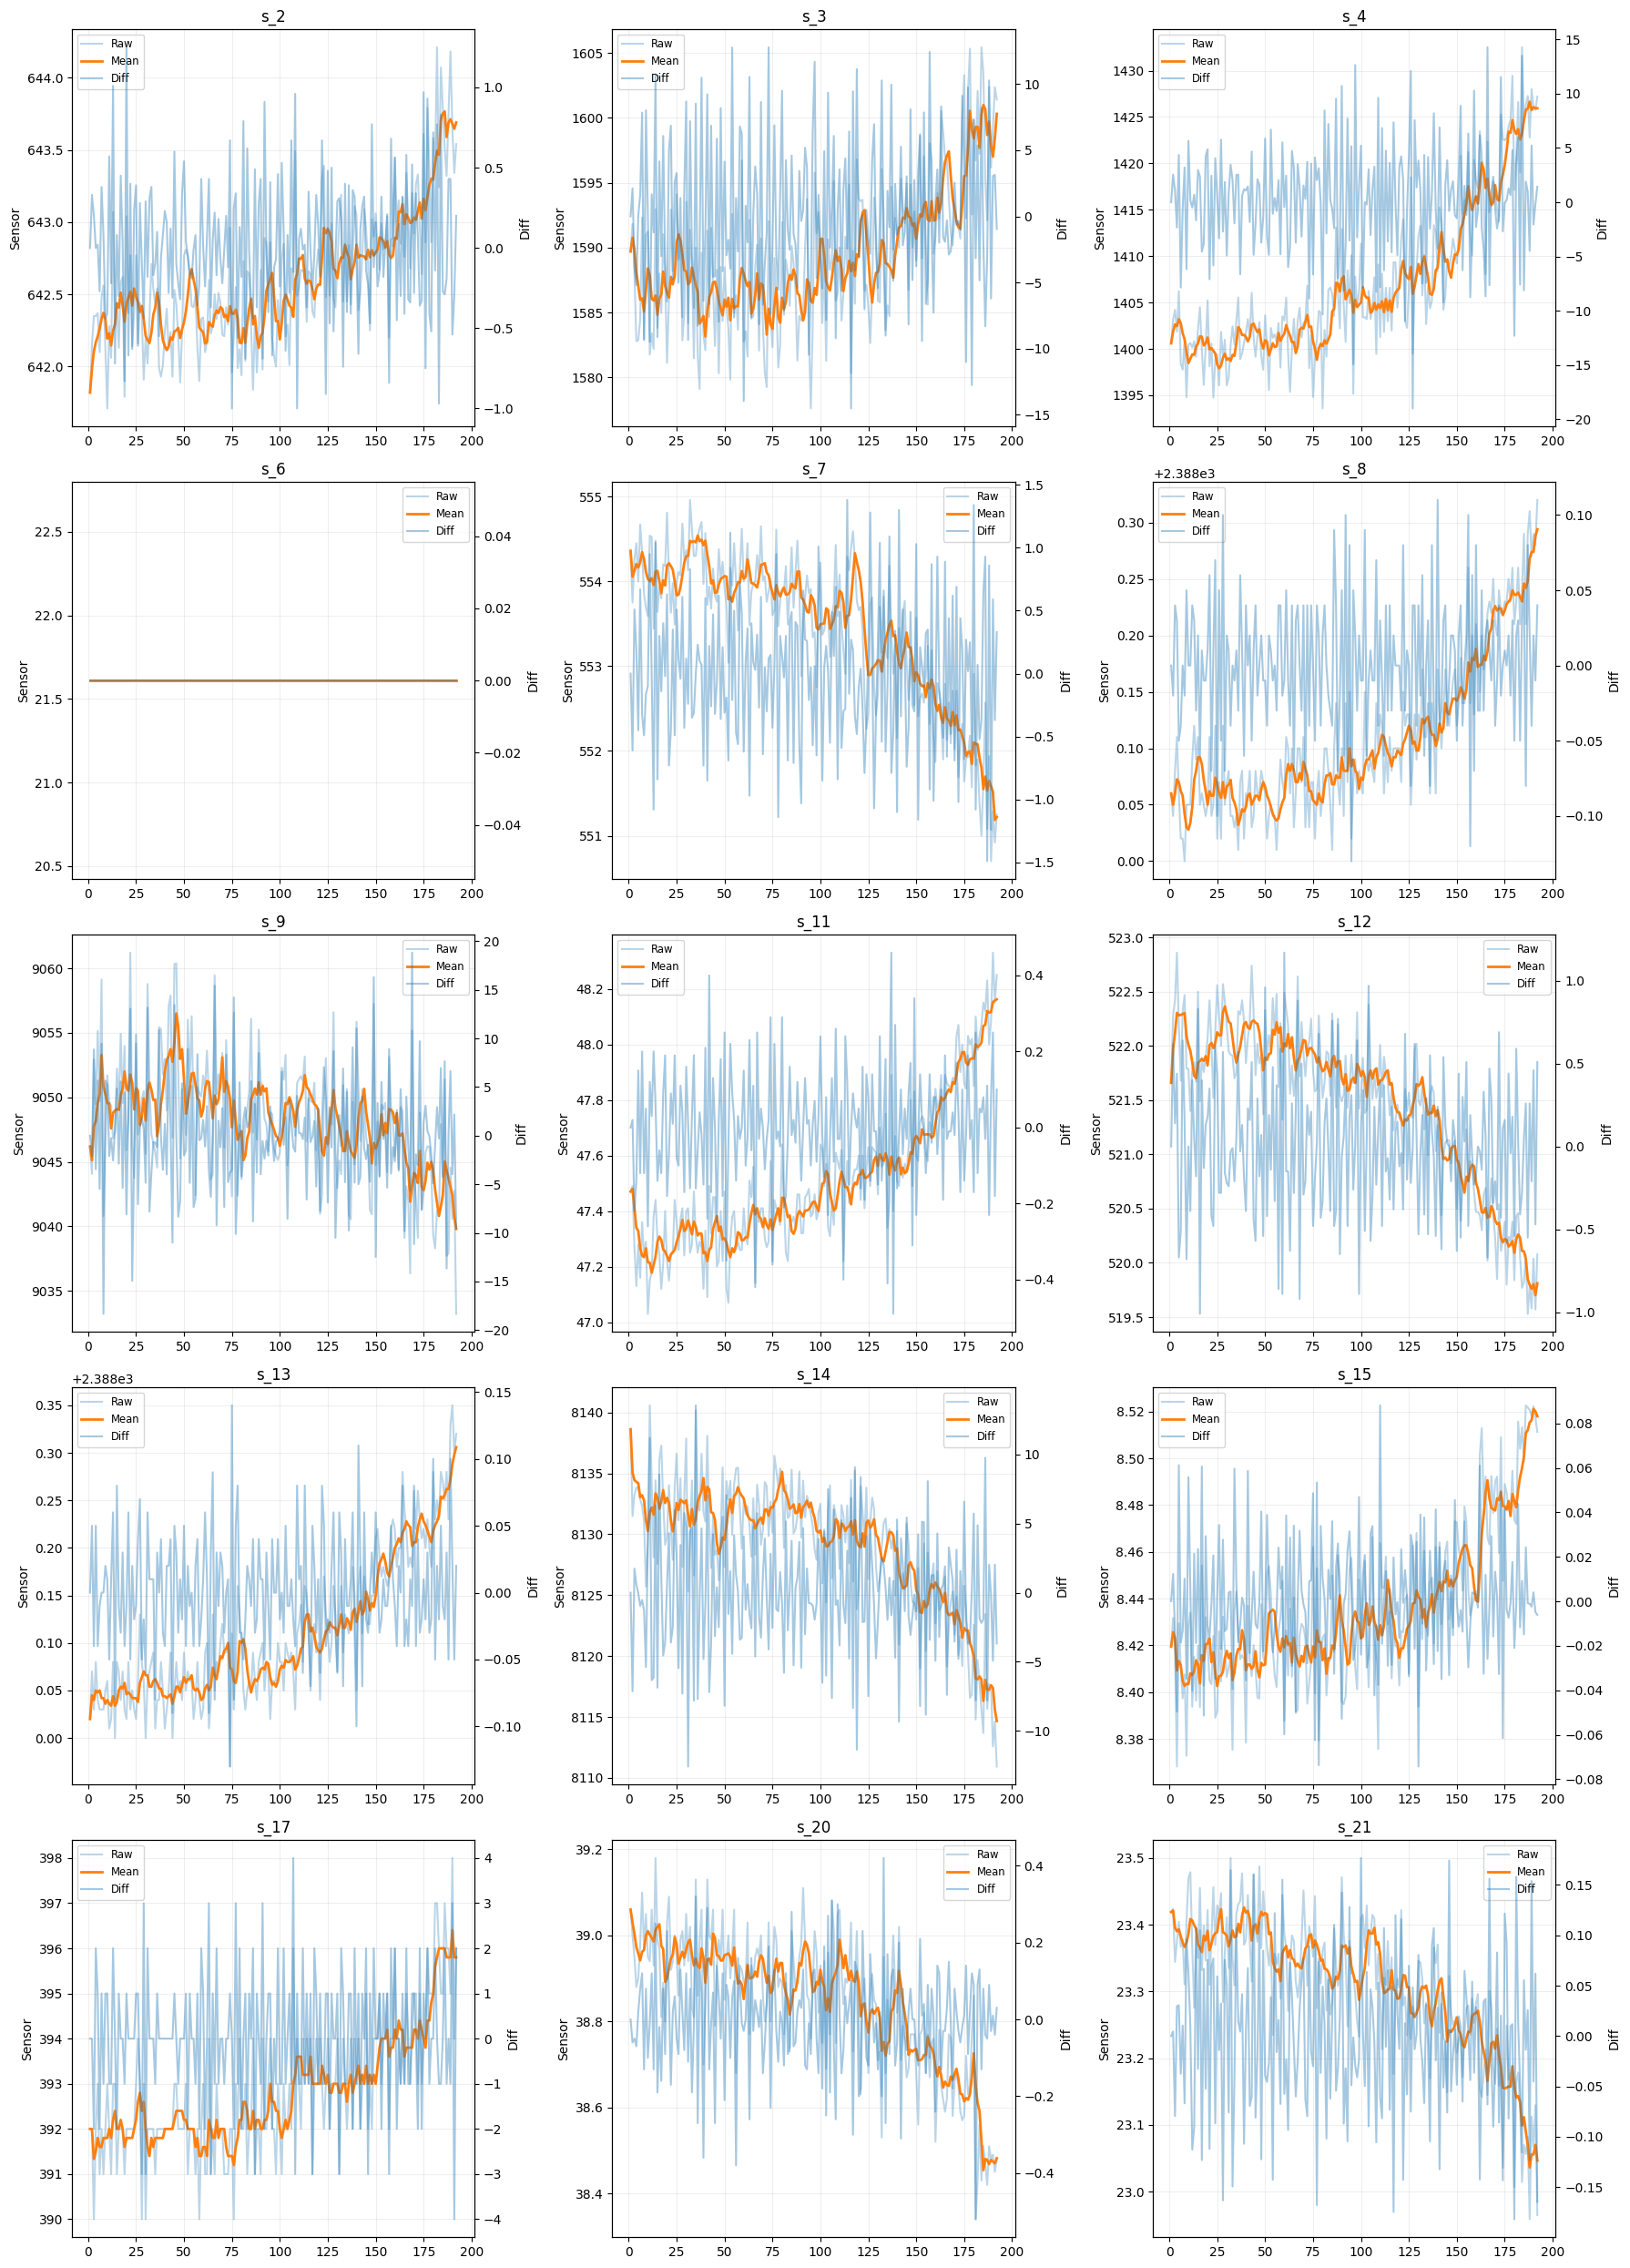

In [ ]:
########## 돌리지 않는 코드 ###############
# 0. 원본 센서만 고정
base_sensors = [col for col in train_df.columns 
                if col.startswith('s_') and col.count('_') == 1]

# 1. 기존 파생 피처 제거 (재실행 안전)
def remove_engineered_features(df):
    return df[[col for col in df.columns 
               if not (col.startswith('s_') and col.count('_') > 1)]].copy()

train_df = remove_engineered_features(train_df)
test_df = remove_engineered_features(test_df)

# 2. 유효 센서 정의
active_sensors = [col for col in base_sensors if train_df[col].std() > 0.001]

# 3. train_df 피처 생성
for col in base_sensors:
    gp = train_df.groupby('unit_nr')[col]
    
    train_df[f'{col}_diff'] = gp.diff()
    train_df[f'{col}_roll_mean'] = gp.transform(lambda x: x.rolling(5, min_periods=1).mean())
    train_df[f'{col}_roll_std'] = gp.transform(lambda x: x.rolling(5, min_periods=1).std())

# 4. test_df 피처 생성
for col in base_sensors:
    gp = test_df.groupby('unit_nr')[col]
    
    test_df[f'{col}_diff'] = gp.diff()
    test_df[f'{col}_roll_mean'] = gp.transform(lambda x: x.rolling(5, min_periods=1).mean())
    test_df[f'{col}_roll_std'] = gp.transform(lambda x: x.rolling(5, min_periods=1).std())

# 5. 결측치 처리
train_df = train_df.fillna(train_df.groupby('unit_nr').ffill()).fillna(0)
test_df = test_df.fillna(test_df.groupby('unit_nr').ffill()).fillna(0)

# 6. unit_1 추출
unit_1 = train_df[train_df['unit_nr'] == 1]

# 7. 시각화 센서 (이제 안전)
pure_sensors = active_sensors

# 8. 그래프
num_sensors = len(pure_sensors)
cols = 3
rows = (num_sensors // cols) + (1 if num_sensors % cols != 0 else 0)

plt.figure(figsize=(18, rows * 5))

for i, sensor in enumerate(pure_sensors):
    ax1 = plt.subplot(rows, cols, i + 1)
    
    ax1.plot(unit_1['time_cycles'], unit_1[sensor], alpha=0.3, label='Raw')
    ax1.plot(unit_1['time_cycles'], unit_1[f'{sensor}_roll_mean'], linewidth=2, label='Mean')
    ax1.set_ylabel('Sensor')

    ax2 = ax1.twinx()
    ax2.plot(unit_1['time_cycles'], unit_1[f'{sensor}_diff'], alpha=0.4, label='Diff')
    ax2.set_ylabel('Diff')

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, fontsize='small')

    plt.title(f'{sensor}')
    ax1.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


# 상승 센서 : 2,3,4,8,11,13,15,17 (필사적으로 버티는 중)
# 하락 센서 : 7,9,12,14,20,21 (힘빠지는중)
# 일정 : 6
# 가파라지는 구간이 변곡점 (지수적 열화)

#roll_std는 눈으로 트렌드를 보는 용도보다는 "기계가 얼마나 불안정한지"를 숫자로 모델에게 알려줄 때 사용하기 때문에 시각화 제외함

C:\Users\skrke\AppData\Local\Temp\ipykernel_19584\2170644982.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10')(np.linspace(0, 1, len(sample_units)))
C:\Users\skrke\AppData\Local\Temp\ipykernel_19584\2170644982.py:54: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


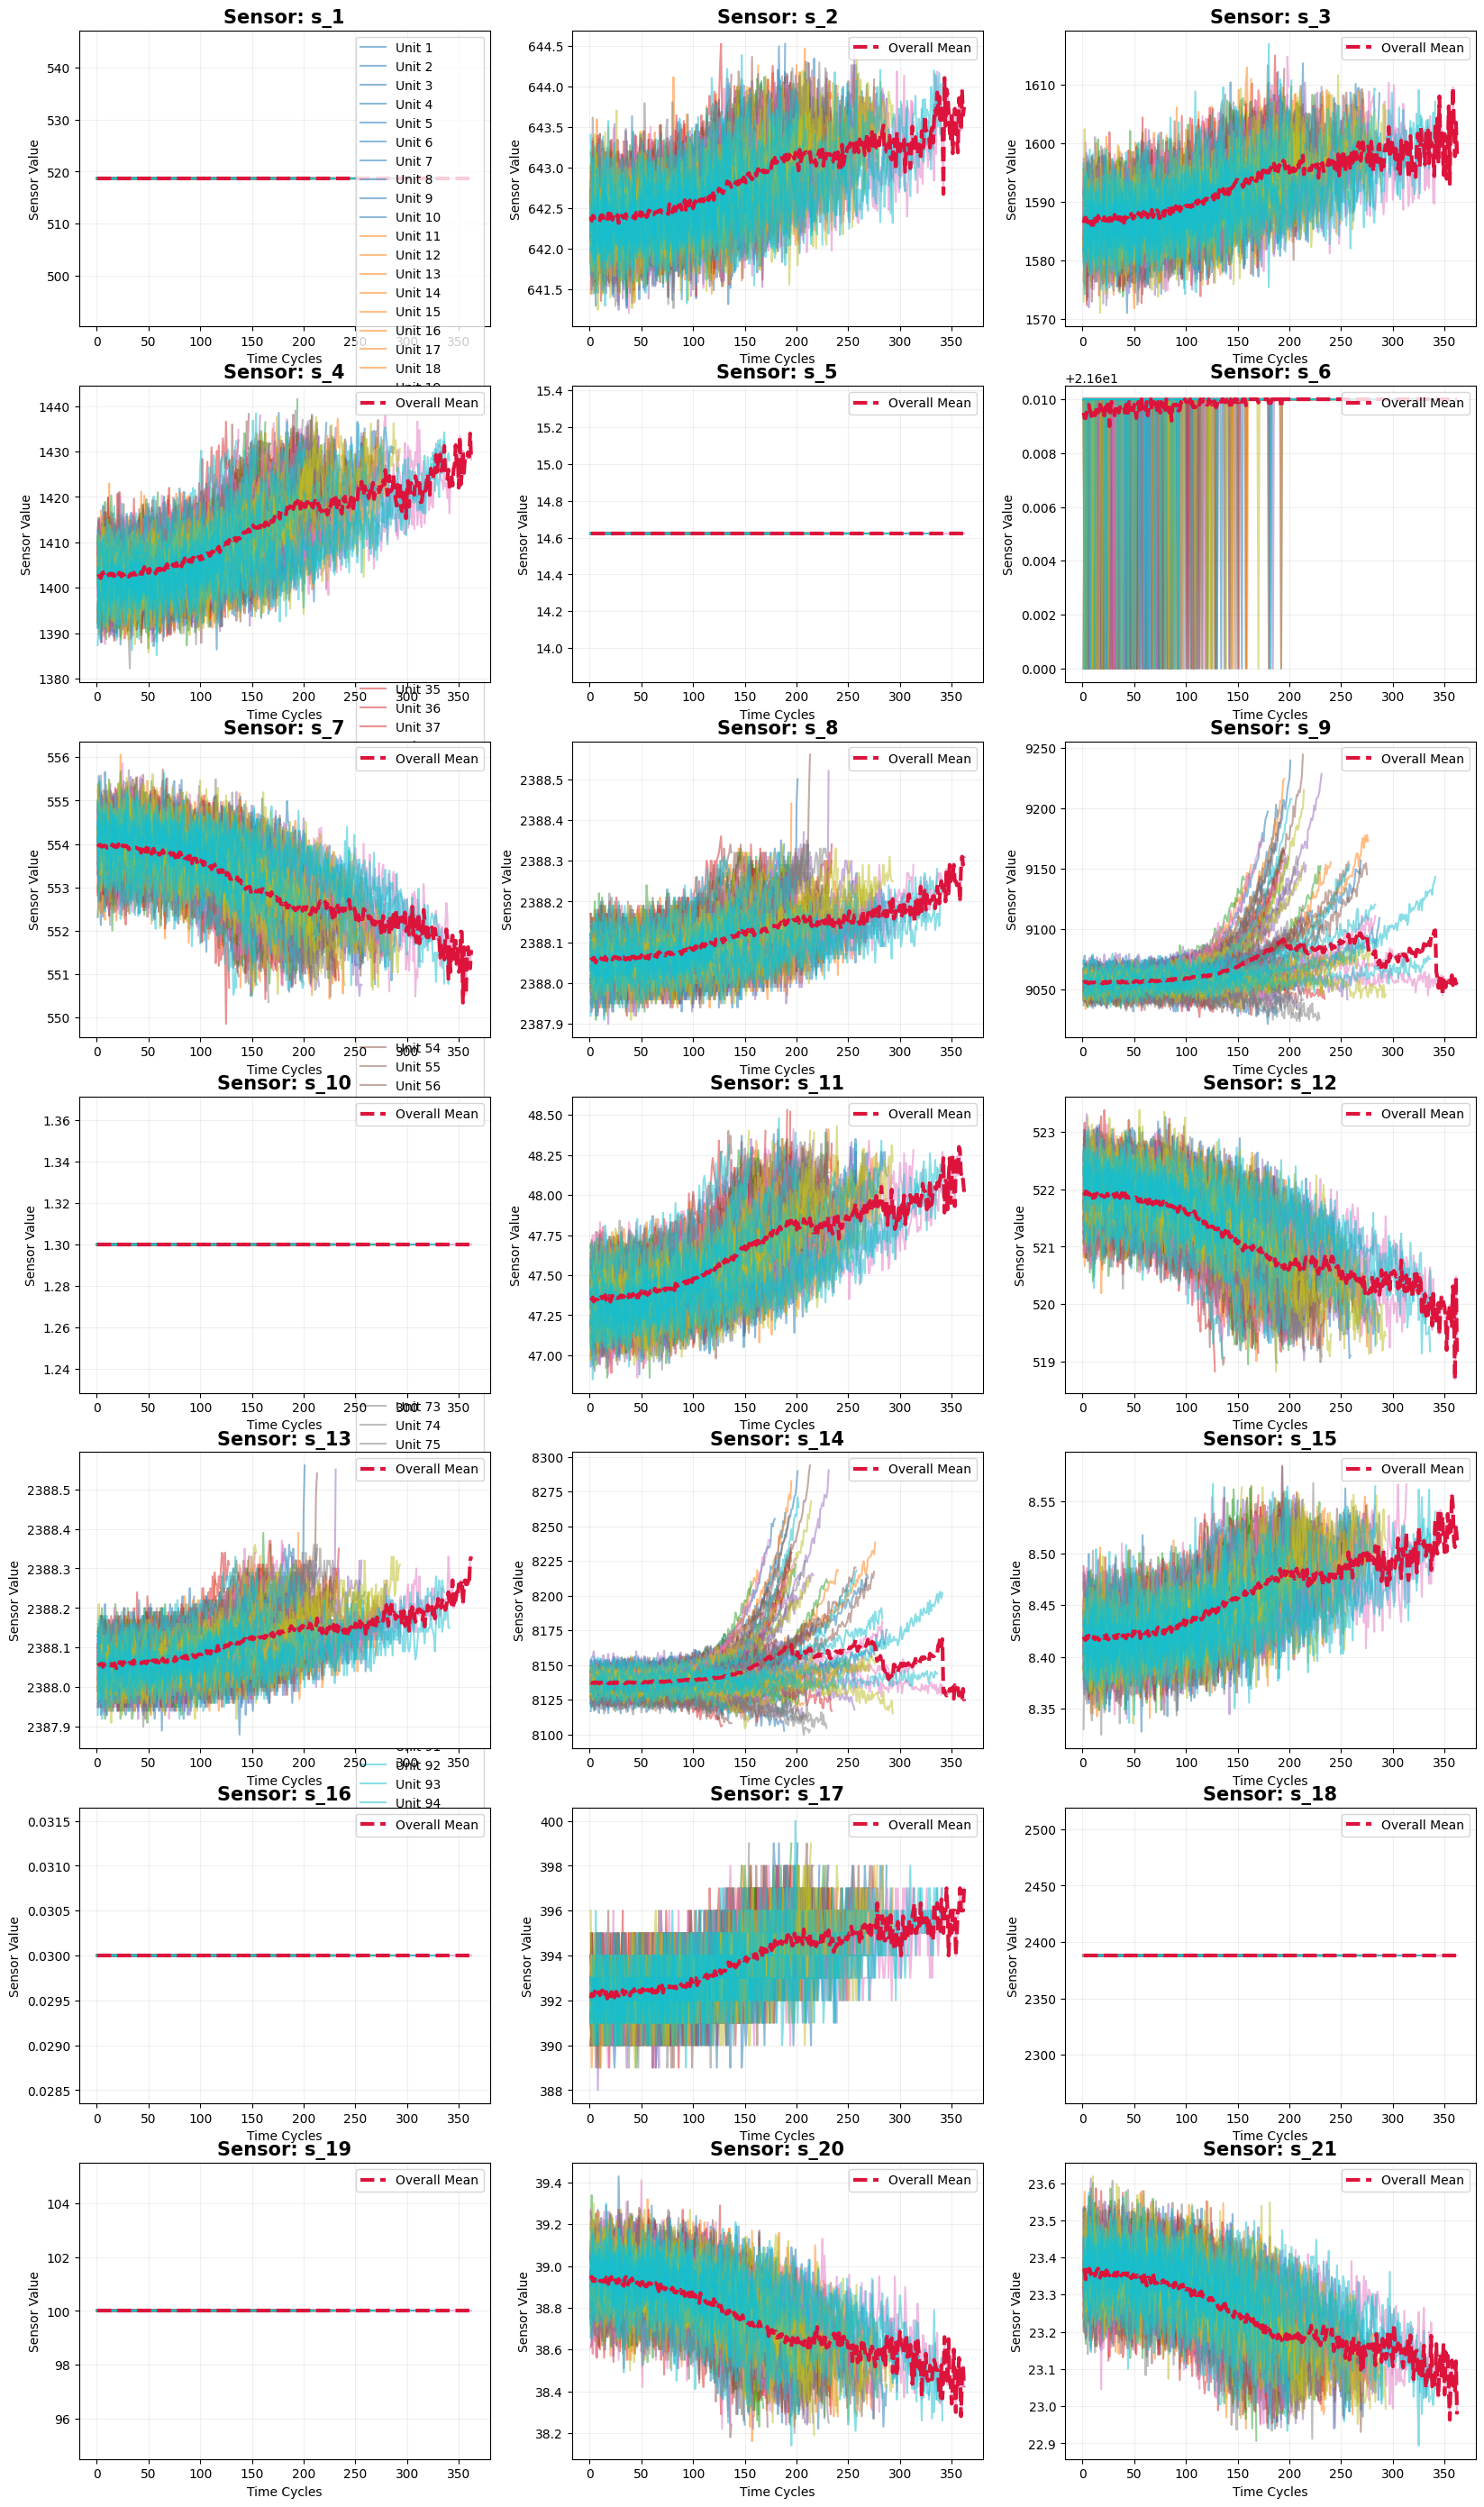

In [ ]:
#################### 돌리지 않는 코드 #################
import math
import matplotlib.cm as cm

# 1. 센서 리스트 및 샘플 유닛 설정
sensors = [col for col in train_df.columns 
           if col.startswith('s_') and col.count('_') == 1]
sample_units = train_df['unit_nr'].unique()[:100]  # 상위 10개 유닛만 샘플링

# 2. 샘플 유닛을 위한 색상 팔레트 생성 (색상을 나누기 위한 핵심!)
colors = cm.get_cmap('tab10')(np.linspace(0, 1, len(sample_units)))
unit_to_color = dict(zip(sample_units, colors))

# 3. 그리드 레이아웃 설정 (가로 3개)
n_cols = 3
n_rows = math.ceil(len(sensors) / n_cols)

# 4. 전체 도화지 생성
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    ax = axes[i]
    
    # [샘플 유닛 데이터 시각화] 각 유닛마다 고유한 색상 적용
    for unit in sample_units:
        unit_data = train_df[train_df['unit_nr'] == unit]
        ax.plot(unit_data['time_cycles'], 
                unit_data[sensor], 
                color=unit_to_color[unit], 
                alpha=0.5,           # 선들이 겹쳐 보이도록 투명도 조절
                label=f'Unit {unit}' if i == 0 else "") # 범례가 너무 많아지므로 첫 플롯에만 표시
    
    # [전체 평균 트렌드 시각화] 아주 굵은 검은색 점선으로 강조
    mean_trend = train_df.groupby('time_cycles')[sensor].mean()
    ax.plot(mean_trend.index, mean_trend.values, 
            linewidth=3, color='crimson', linestyle='--', label='Overall Mean')
    
    # 그래프 스타일 설정
    ax.set_title(f'Sensor: {sensor}', fontsize=15, fontweight='bold')
    ax.set_xlabel('Time Cycles')
    ax.set_ylabel('Sensor Value')
    
    # 첫 번째 그래프에만 유닛 범례를 표시하거나, 깔끔하게 평균만 표시
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.2)

# 5. 빈 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. 레이아웃 자동 조정 및 출력
plt.tight_layout()
plt.show()

# 피처 선택

In [13]:
# 상수센서 제거
# 1. 검사 대상을 s_1 ~ s_21 센서 컬럼으로 한정
sensor_cols = [col for col in train_df.columns if col.startswith('s_')]

# 2. 센서들의 표준편차 계산
sensor_std = train_df[sensor_cols].std()
print(sensor_std)

# 3. 표준편차가 0인 센서 컬럼 식별
constant_sensors = sensor_std[sensor_std == 0].index.tolist()

print(f"검사 대상 센서 개수: {len(sensor_cols)}개")
print(f"제거될 상수 센서(s_xx): {constant_sensors}")

# 4. 데이터프레임에서 해당 상수 센서만 제거
train_df.drop(columns=constant_sensors, inplace=True)

# 5. 최종 남은 컬럼 확인 (setting_1~3은 그대로 유지됨)
print(f"최종 남은 컬럼 예시: {train_df.columns.tolist()}")

s_1     0.000000e+00
s_2     5.000533e-01
s_3     6.131150e+00
s_4     9.000605e+00
s_5     5.329200e-15
s_6     1.388985e-03
s_7     8.850923e-01
s_8     7.098548e-02
s_9     2.208288e+01
s_10    0.000000e+00
s_11    2.670874e-01
s_12    7.375534e-01
s_13    7.191892e-02
s_14    1.907618e+01
s_15    3.750504e-02
s_16    3.469531e-18
s_17    1.548763e+00
s_18    0.000000e+00
s_19    0.000000e+00
s_20    1.807464e-01
s_21    1.082509e-01
dtype: float64
검사 대상 센서 개수: 21개
제거될 상수 센서(s_xx): ['s_1', 's_10', 's_18', 's_19']
최종 남은 컬럼 예시: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_20', 's_21', 'RUL']


# 전처리 (가우시안필터 / 정규화 / window) 조정

In [14]:
# --- 실험 설정값  ---
CONFIG = {
    'RUL_CAP': 125,            # RUL Clipping 값 (이 경우 125이하만 가능)
    'GAUSSIAN_SIGMA': 2,       # 가우시안 필터 알파(sigma)
    'WINDOW_SIZE': 30,         # 슬라이딩 윈도우 크기
    'SCALER_TYPE': 'minmax'    # 'minmax' 또는 'standard'
}

In [15]:
def preprocess_pipeline(df, config):
    # 복사본 생성
    data = df.copy()
    features = [col for col in data.columns if col.startswith('s_') or col.startswith('setting')]
    
    # 1. RUL Clipping
    data['RUL'] = data['RUL'].clip(upper=config['RUL_CAP'])
    
    # 2. 가우시안 필터 적용
    from scipy.ndimage import gaussian_filter1d
    for unit in data['unit_nr'].unique():
        mask = data['unit_nr'] == unit
        for col in features:
            data.loc[mask, col] = gaussian_filter1d(data.loc[mask, col], sigma=config['GAUSSIAN_SIGMA'])
            
    # 3. 정규화
    from sklearn.preprocessing import MinMaxScaler, StandardScaler
    scaler = MinMaxScaler() if config['SCALER_TYPE'] == 'minmax' else StandardScaler()
    data[features] = scaler.fit_transform(data[features])
    
    return data, features

# 실행 예시
processed_df, final_features = preprocess_pipeline(train_df, CONFIG)

In [16]:
# 슬라이딩 윈도우 데이터 생성 (Window Size=위에서 지정된 사이즈)
def create_window_dataset(df, window_size=30, feature_cols=None):
    X, y = [], []
    for unit in df['unit_nr'].unique():
        unit_df = df[df['unit_nr'] == unit]
        if len(unit_df) >= window_size:
            data_values = unit_df[feature_cols].values
            target_values = unit_df['RUL'].values
            for i in range(len(unit_df) - window_size + 1):
                X.append(data_values[i:i+window_size, :])
                y.append(target_values[i+window_size-1])
    return np.array(X), np.array(y)

# 2. 전처리 완료된 데이터를 사용하여 윈도우 생성
current_window_size = CONFIG['WINDOW_SIZE']

X_train, y_train = create_window_dataset(processed_df, current_window_size, final_features)

# 3. 결과 확인
print(f"--- 데이터 변환 완료 ---")
print(f"X_train Shape (샘플 수, 타임스텝, 피처 수): {X_train.shape}")
print(f"y_train Shape (타겟 수): {y_train.shape}")

--- 데이터 변환 완료 ---
X_train Shape (샘플 수, 타임스텝, 피처 수): (17731, 30, 20)
y_train Shape (타겟 수): (17731,)


# 모델 하이퍼파라미터(학습 횟수, 은닉층, 레이어 수) 튜닝

In [18]:
# pip install tensorflow 파워셀 실행

# 1. 모델 생성 함수 정의
# 실험을 편하게 하기 위해 레이어 수와 노드 수를 인자로 받는 함수를 만들기
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def build_lstm_model(input_shape, hidden_units=64, num_layers=2, dropout_rate=0.2):
    model = Sequential()
    
    # 첫 번째 LSTM 레이어 (input_shape 필요)
    model.add(LSTM(units=hidden_units, 
                   return_sequences=True if num_layers > 1 else False, 
                   input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    
    # 중간 LSTM 레이어들
    for i in range(num_layers - 1):
        # 마지막 LSTM 레이어면 return_sequences를 False로 설정
        is_last = (i == num_layers - 2)
        model.add(LSTM(units=hidden_units, return_sequences=not is_last))
        model.add(Dropout(dropout_rate))
    
    # 출력층 (Regression이므로 활성화 함수 없이 1개 노드)
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# 2. 하이퍼파라미터 설정 및 학습 실행
# 여기서 EPOCHS, BATCH_SIZE, HIDDEN_UNITS 등을 조절하며 실험

from tensorflow.keras.callbacks import EarlyStopping

# --- 1. 모델 하이퍼파라미터 설정---
HYPERPARAMS = {
    'HIDDEN_UNITS': 64,    # 은닉층 노드 수
    'NUM_LAYERS': 2,       # LSTM 레이어 개수
    'DROPOUT': 0.2,        # 과적합 방지 드롭아웃
    'BATCH_SIZE': 32,      # 한 번에 학습할 샘플 수
    'EPOCHS': 50           # 최대 학습 횟수 (EarlyStopping이 이보다 빨리 멈출 수 있음)
}

# --- 2. 조기 종료(EarlyStopping) 정의 ---
es = EarlyStopping(
    monitor='val_loss', 
    patience=10,            # 10번 참아보고 안 나아지면 종료
    restore_best_weights=True  # 가장 성적이 좋았던 때의 가중치로 복구
)

# --- 3. 모델 빌드 ---
input_shape = (X_train.shape[1], X_train.shape[2]) 
model = build_lstm_model(
    input_shape, 
    hidden_units=HYPERPARAMS['HIDDEN_UNITS'],
    num_layers=HYPERPARAMS['NUM_LAYERS'],
    dropout_rate=HYPERPARAMS['DROPOUT']
)

model.summary()

# --- 4. 학습 시작 ---
history = model.fit(
    X_train, y_train,
    epochs=HYPERPARAMS['EPOCHS'],
    batch_size=HYPERPARAMS['BATCH_SIZE'],
    validation_split=0.2, 
    callbacks=[es],       # 설정해둔 조기 종료 적용
    verbose=1
)

In [ ]:
# 결과 시각화
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()